In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# SUFFIX = "_normalized"
SUFFIX = ""

sns.set_theme(font="Times New Roman",palette="pastel")

pd.options.display.float_format = '{:,.2f}'.format

def filter_iqr(df,groupby, col):
    """
    filter_iqr(df,["A","B"],"C")
    """
    threshold = 1.5
    groups = df.groupby(by=groupby)
    filt =  groups.apply(lambda g: g[~((g[col] < g[col].quantile(0.25) - threshold * (g[col].quantile(0.75) - g[col].quantile(0.25))) | (g[col] > g[col].quantile(0.75) + threshold * (g[col].quantile(0.75) - g[col].quantile(0.25))))])
    outliers =  groups.apply(lambda g: g[(g[col] < g[col].quantile(0.25) - threshold * (g[col].quantile(0.75) - g[col].quantile(0.25))) | (g[col] > g[col].quantile(0.75) + threshold * (g[col].quantile(0.75) - g[col].quantile(0.25)))])
    return filt,outliers

In [36]:
import json 
with open(f"./losses{SUFFIX}.json") as f:
    losses = json.load(f)


# Analysis with outliers

In [37]:
def rename_model(name):
    if name == "Encoder":
        return "ECT-MLP"
    elif name == "EncoderScaled":
        return "ECT-MLP-N"
    elif name == "VAE":
        return "ECT-VAE"
    else: 
        return name

In [38]:
df_losses = pd.DataFrame(losses).drop("idx",axis=1)
df_losses["Loss_cd"] = df_losses["Loss_cd"] * 1e4
df_losses["Loss_emd"] = df_losses["Loss_emd"] * 1e3
df_losses.rename(columns={'Loss_cd': 'CD', 'Loss_emd': 'EMD'}, inplace=True)
df_losses["Model"] = df_losses["Model"].apply(rename_model)
df_losses = df_losses.melt(id_vars=["Model", "Category"], ignore_index=False,value_name="Loss",var_name="Type")
df_losses.head()

,Model,Category,Type,Loss
0,ECT-MLP,Airplane,EMD,6.49
1,ECT-MLP,Airplane,EMD,13.29
2,ECT-MLP,Airplane,EMD,9.00
3,ECT-MLP,Airplane,EMD,7.59
4,ECT-MLP,Airplane,EMD,3.54


## Table with the outliers included

In [39]:
df_table = df_losses.groupby(by=["Model","Type","Category"]).agg({"Loss":["mean","std"]}).unstack().unstack()
df_table.columns = df_table.columns.swaplevel(1, 2).swaplevel(2,3)
df_table.sort_index(axis=1, level=0, inplace=True)
cols = df_table.columns.to_list()
mulidx = pd.MultiIndex.from_tuples(cols[:4]+cols[-4:]+cols[4:-4],names=df_table.columns.names)
df_table.columns = mulidx

df_table


Loss                                                             \
Category  Airplane                  Chair                     Car               
Type            CD        EMD          CD         EMD          CD         EMD   
              mean  std  mean   std  mean   std  mean   std  mean   std  mean   
Model                                                                           
ECT-MLP       6.65 6.83 11.03  7.36 10.09 38.32 11.87  9.41 14.49 14.22 19.61   
ECT-MLP-N     1.16 0.64  3.28  1.40  6.37  2.04  7.60  3.56 10.41 10.07 13.09   
ECT-VAE       1.67 1.37  5.09  2.41 10.17  3.96 11.49  5.09 16.01 14.39 18.42   
PointFlow     5.12 5.73 12.99 13.50  9.73 38.79 14.32 12.83 10.32 10.70 18.25   
ShapeGF       3.64 4.26  8.91  6.51  8.01 29.60 10.16  8.22  6.13  4.12 12.51   
SoftFlow      6.48 8.81 12.28 11.36  9.84 35.33 12.74 10.30 11.35 13.14 17.83   

                 
Category         
Type             
            std  
Model            
ECT-MLP   13.59  
ECT-MLP-N  9.44  
ECT-VAE   12.60  
PointFlow 12.22  
ShapeGF    7.42  
SoftFlow  11.43

In [40]:
with open(f"./tables/loss_table{SUFFIX}.tex","w") as f:
    df_table.style.format("{:.2f}").to_latex(f,siunitx=True,multicol_align="c")


# Critical Differences Plot

In [41]:
LOSS_TYPE = "EMD"
df_crit = df_table.xs("Loss",axis=1).xs(LOSS_TYPE,level=1,axis=1).xs("mean",level=1,axis=1).T
df_crit

Model,ECT-MLP,ECT-MLP-N,ECT-VAE,PointFlow,ShapeGF,SoftFlow
Category,,,,,,
Airplane,11.03,3.28,5.09,12.99,8.91,12.28
Chair,11.87,7.60,11.49,14.32,10.16,12.74
Car,19.61,13.09,18.42,18.25,12.51,17.83


In [42]:
from critdd import Diagram

# create a CD diagram from the Pandas DataFrame
diagram = Diagram(
    df_crit.to_numpy(),
    treatment_names = df_crit.columns,
    maximize_outcome = True
)

# inspect average ranks and groups of statistically indistinguishable treatments
diagram.average_ranks # the average rank of each treatment
diagram.get_groups(alpha=.05, adjustment="holm")

# export the diagram to a file
diagram.to_file(
    f"critical_differences_{LOSS_TYPE}{SUFFIX}.tex",
    alpha = .05,
    adjustment = "holm",
    reverse_x = True,
    axis_options = {"title": "critdd"},
)

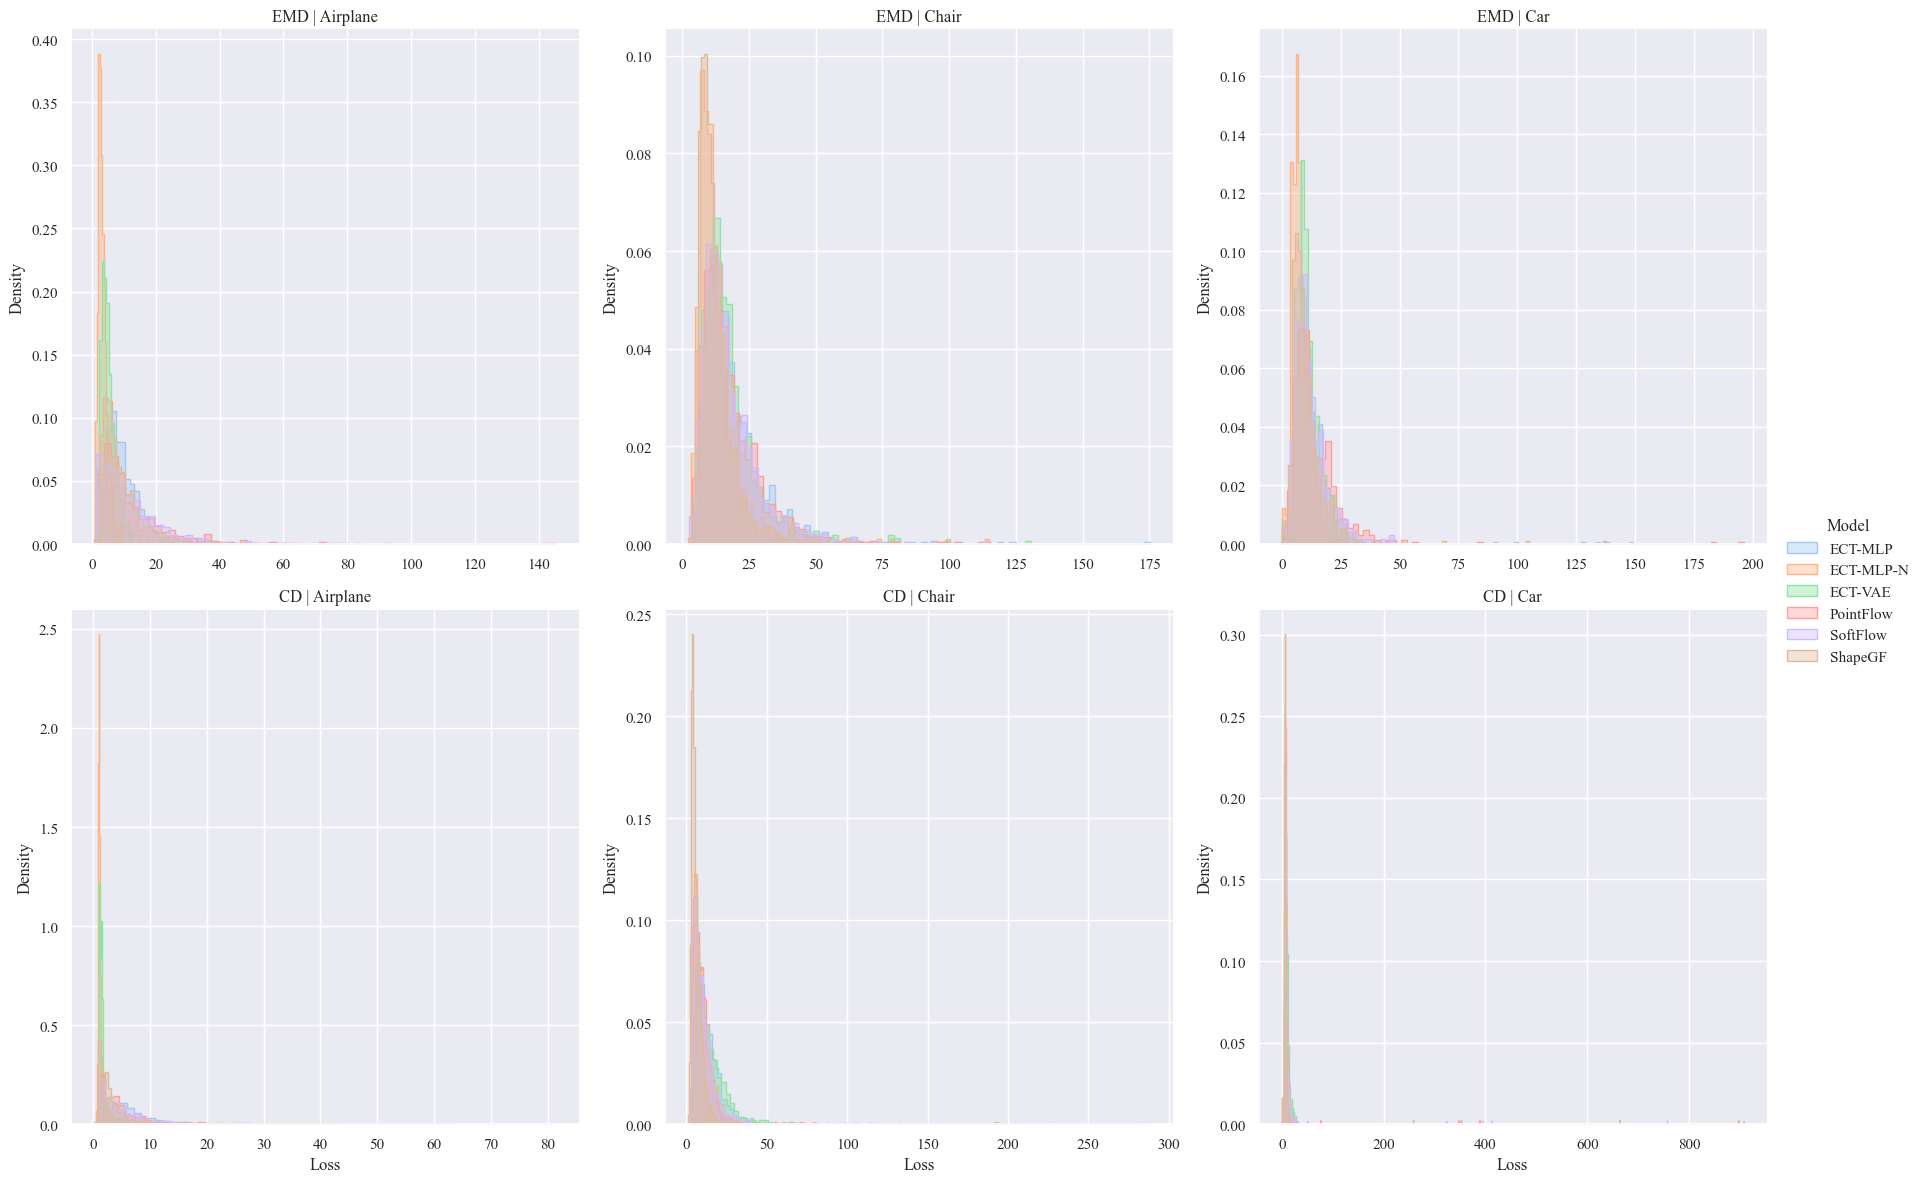

In [43]:
g = sns.FacetGrid(df_losses,col="Category",hue="Model", row="Type", sharex=False, sharey=False,height=6);
g.map(sns.histplot,"Loss",element="step",alpha=.4, stat='density', common_norm=False);
g.set(ylim=(0, None));
# g.set_axis_labels("Density")
g.set_titles(col_template="{col_name}", row_template="{row_name}")
g.add_legend();
plt.savefig(f"./figures/loss_histogram{SUFFIX}.png",dpi=500,transparent=True)

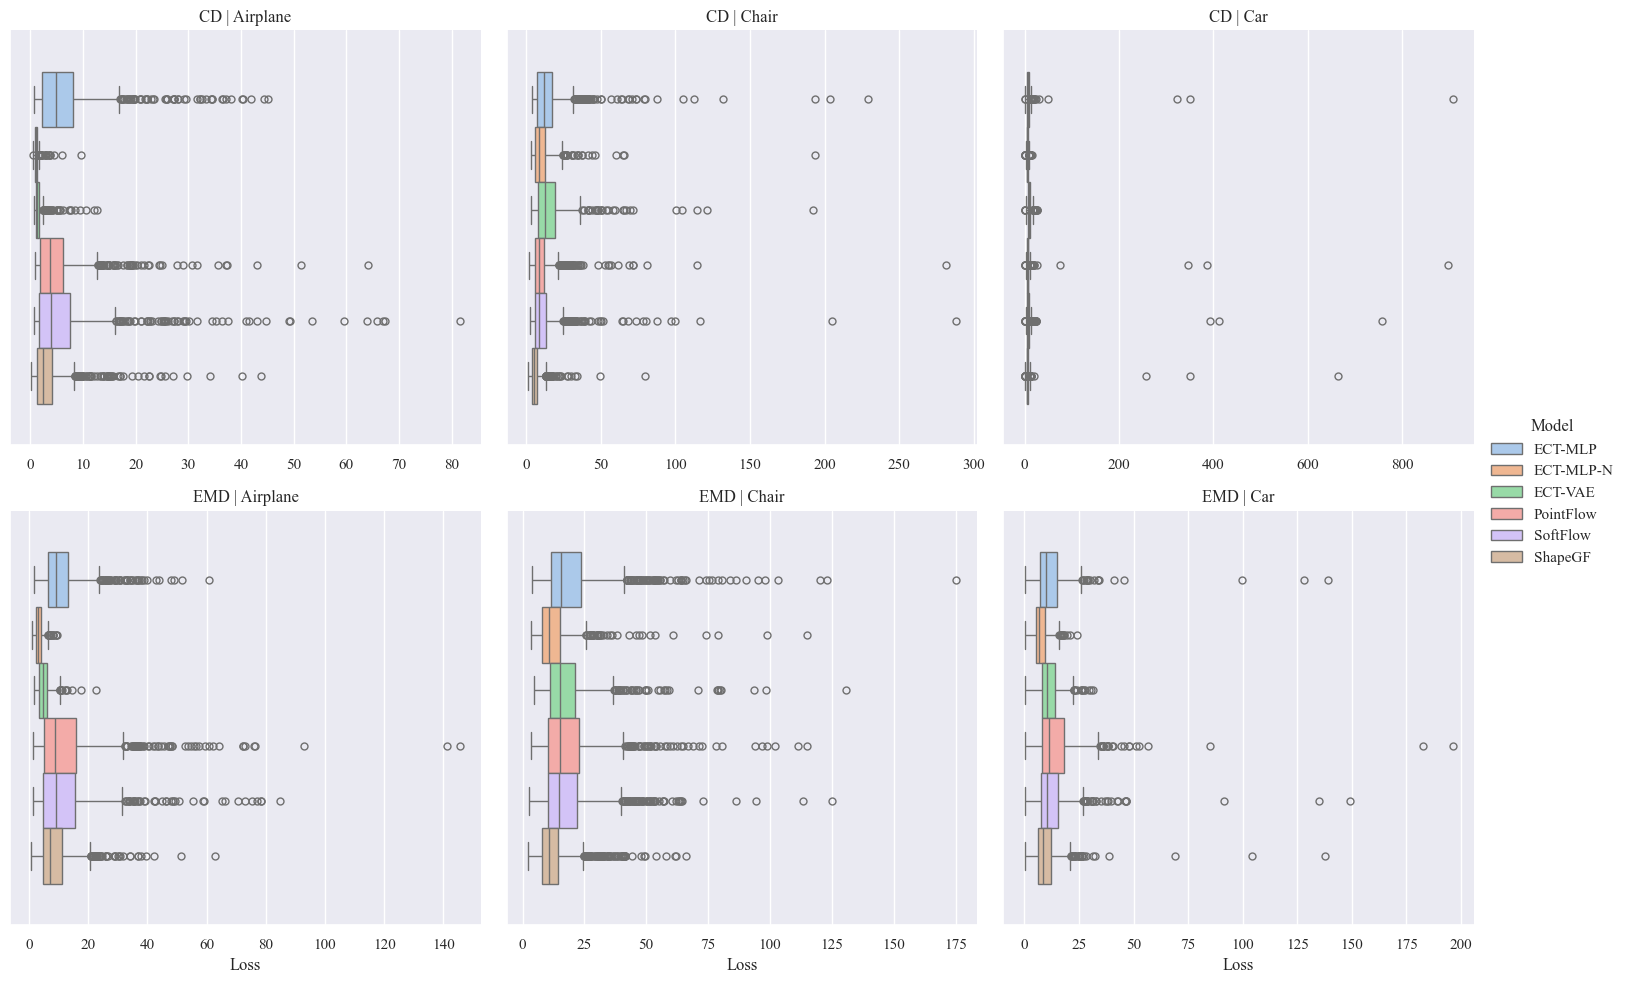

In [44]:
g = sns.catplot(df_losses.reset_index(drop=True),x="Loss",col="Category",row="Type",hue="Model",kind="box",sharex=False,row_order=["CD","EMD"]);
g.set_titles(col_template="{col_name}", row_template="{row_name}")
plt.savefig(f"./figures/loss_boxplot{SUFFIX}.png",dpi=500,transparent=False)

# Analysis without outliers

In [45]:
df_losses_filtered,outliers = filter_iqr(df_losses,["Model","Category","Type"],"Loss")
df_losses_filtered = df_losses_filtered.reset_index(drop=True)

In [46]:
df_table = df_losses_filtered.groupby(by=["Model","Type","Category"]).agg({"Loss":["mean","std"]}).unstack().unstack()
df_table.columns = df_table.columns.swaplevel(1, 2).swaplevel(2,3)
df_table.sort_index(axis=1, level=0, inplace=True)
cols = df_table.columns.to_list()
mulidx = pd.MultiIndex.from_tuples(cols[:4]+cols[-4:]+cols[4:-4],names=df_table.columns.names)
df_table.columns = mulidx
df_table

Loss                                                            
Category  Airplane                 Chair                   Car                
Type            CD        EMD         CD        EMD         CD        EMD     
              mean  std  mean  std  mean  std  mean  std  mean  std  mean  std
Model                                                                         
ECT-MLP       5.13 3.65  9.53 4.36  7.45 2.42 10.96 5.14 12.34 6.19 17.21 7.97
ECT-MLP-N     1.04 0.18  3.10 1.09  6.23 1.45  7.26 3.01  9.19 4.65 11.45 4.70
ECT-VAE       1.33 0.34  4.85 1.91  9.60 2.77 10.93 4.25 13.73 7.24 15.95 6.91
PointFlow     3.92 2.76 10.09 6.66  6.94 1.89 12.84 6.81  8.98 4.11 16.48 8.27
ShapeGF       2.65 1.67  7.79 4.26  6.15 1.62  9.11 4.14  5.62 2.43 11.08 4.38
SoftFlow      4.48 3.60 10.35 7.01  7.22 2.04 11.32 5.34  9.47 4.78 16.00 7.62

In [47]:
with open(f"./tables/loss_table_filtered{SUFFIX}.tex","w") as f:
    df_table.style.format("{:.2f}").to_latex(f,siunitx=True,multicol_align="c")

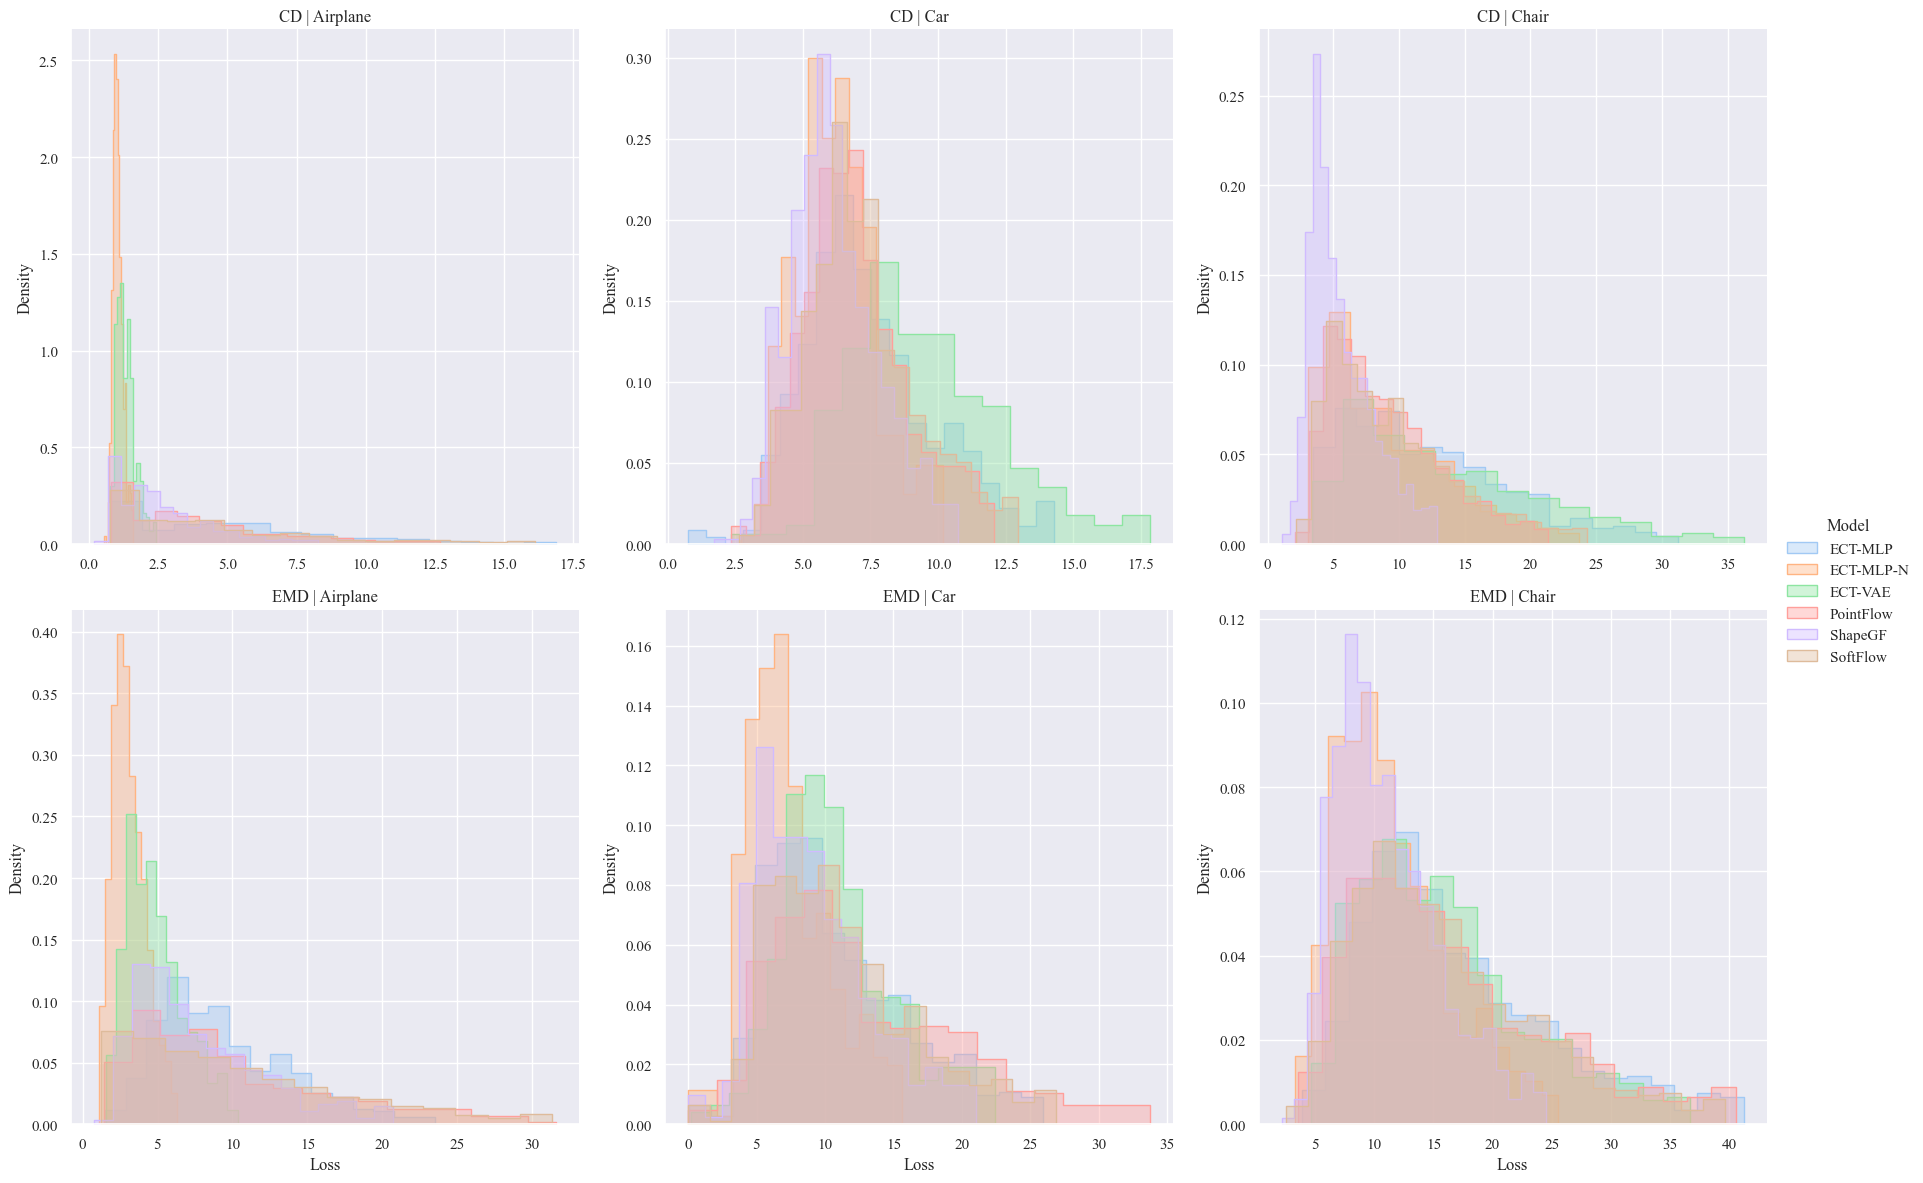

In [48]:
g = sns.FacetGrid(df_losses_filtered,col="Category",hue="Model", row="Type", sharex=False, sharey=False,height=6);
g.map(sns.histplot,"Loss",element="step",alpha=.4, stat='density', common_norm=False);
g.set(ylim=(0, None));
# g.set_axis_labels("Density")
g.set_titles(col_template="{col_name}", row_template="{row_name}")
g.add_legend();
plt.savefig(f"./figures/loss_histogram_filtered{SUFFIX}.png",dpi=500,transparent=False)

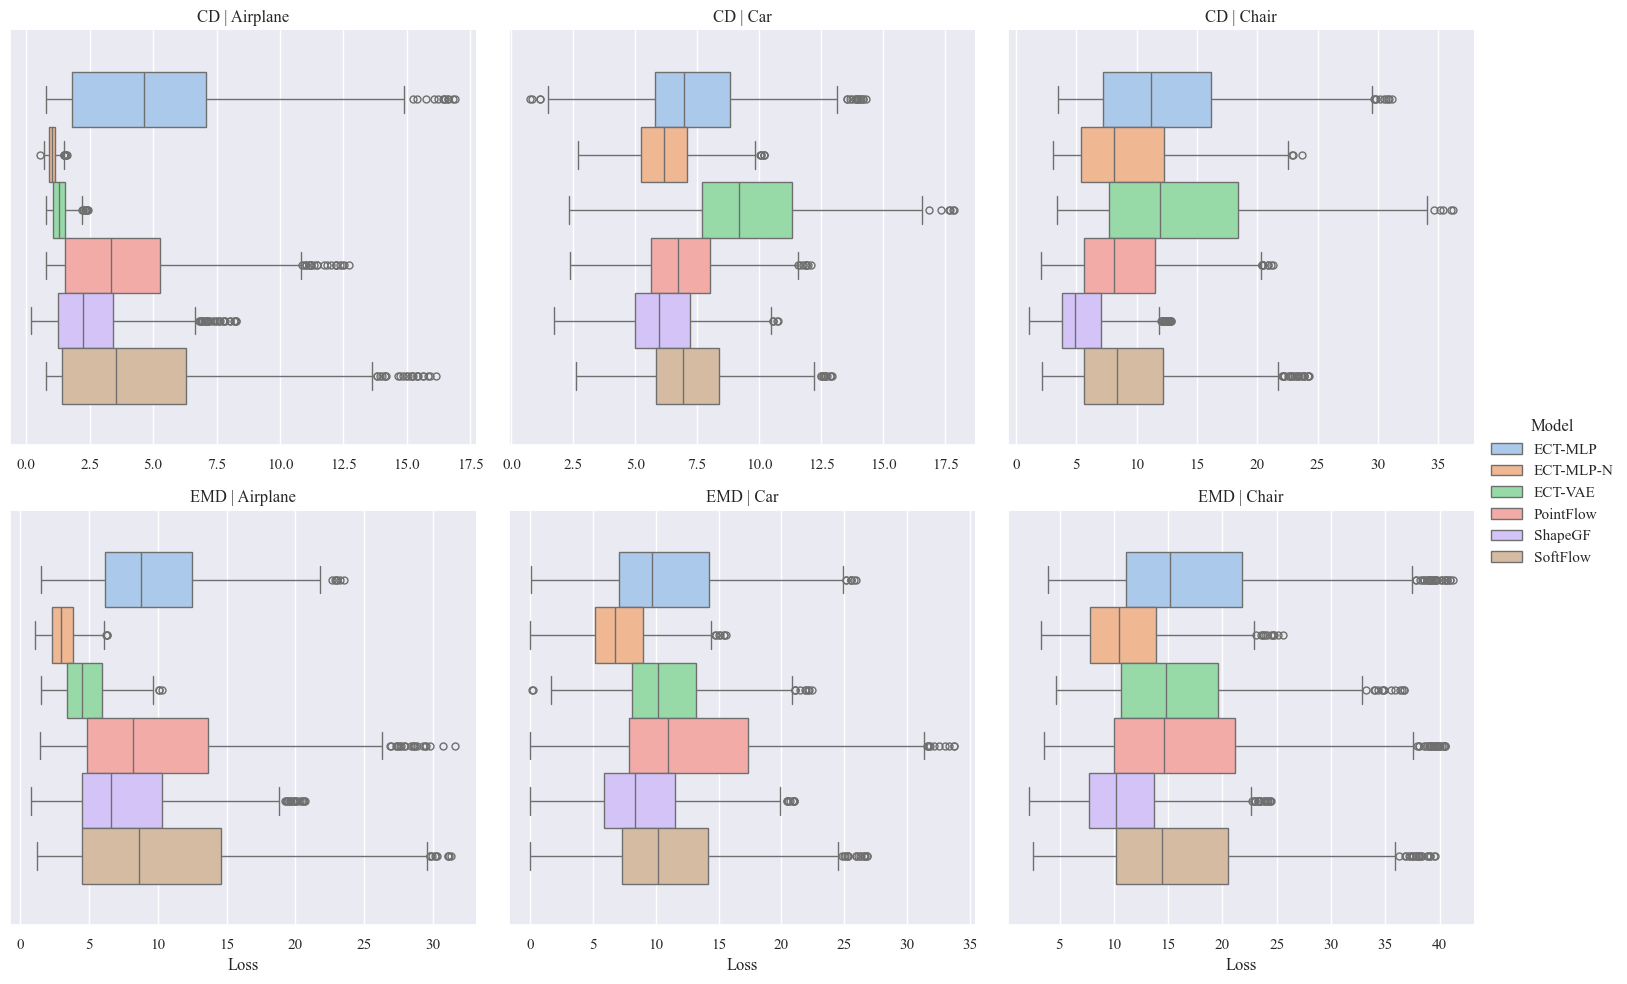

In [49]:
g = sns.catplot(df_losses_filtered.reset_index(drop=True),x="Loss",col="Category",row="Type",hue="Model",kind="box",sharex=False,row_order=["CD","EMD"]);
g.set_titles(col_template="{col_name}", row_template="{row_name}")
plt.savefig(f"./figures/loss_boxplot_filtered{SUFFIX}.png",dpi=500,transparent=False)

# Elements in the validation set with the largest loss

In [50]:
# theta = torch.tensor(.5*torch.pi)
# # m = torch.tensor([[1, 0, 0], [0, torch.cos(theta), torch.sin(theta)], [0, -torch.sin(theta), torch.cos(theta)]]).cuda()
# m = torch.tensor([[torch.cos(theta), 0, -torch.sin(theta)], [0, 1, 0], [torch.sin(theta), 0, torch.cos(theta)]]).cuda()
# for model in MODELS:
#     for cat in CATES:
#         print(80*"#")
#         print("###", model.upper(), cat.upper())
#         print(80*"#")
#         df_car = df_losses[df_losses["cate"]==cat]
#         df_idx = df_car[df_car["model"] == model].sort_values(by="Loss",ascending=False) 
#         car_outlier_idx = df_idx["idx"].values.tolist()
#         sample_pcs = torch.load(f'./results/{model}/samples_{cat}{SUFFIX}.pt')
#         ref_pcs = torch.load(f'./results/{model}/ref_{cat}{SUFFIX}.pt')
#         outlier_refs = ref_pcs[car_outlier_idx]
#         outlier_smp = sample_pcs[car_outlier_idx] 

#         jnt_pcs = torch.cat([outlier_smp,outlier_refs],axis=1)
#         plot_pcs_recon(outlier_refs, outlier_smp,jnt_pcs)